In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, os
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'

# Import prediction data with mecidal parameteres

In [2]:
df = pd.read_csv("../data/systemic_params.csv", index_col=0)

In [3]:
df.rename(columns={"rVAI (%)":"rmVAI (%)",
                   "Hb":"Hb (g/dL)",
                   "CRP":"CRP (mg/dL)",
                   "RF":"RF (IU/mL)",
                   "TP": "TP (g/dL)",
                   "Alb": "Alb (g/dL)",
                   "GOT":"AST (Unit/L)",
                   "GPT": "ALT (Unit/L)",
                   "γGTP":"γGTP (Unit/L)", 
                   "AMY":"AMY (Unit/L)", 
                   
                   "Waist (cm)": "Waist circumference (cm)",}, inplace=True)

In [4]:
df = df.rename(columns=lambda x: x.replace("mg/dl", "mg/dL"))

In [5]:
df.columns

Index(['Age', 'Predicted_age', 'SEX', 'Height (cm)', 'Weight (kg)',
       'Waist circumference (cm)', 'WBC ($10^{3}/mm^{3}$)',
       'RBC ($10^{3}/mm^{3}$)', 'Hb (g/dL)', 'Ht (%)', 'MCV', 'MCH', 'MCHC',
       'Plt ($10^{3}/mm^{3}$)', 'CRP (mg/dL)', 'RF (IU/mL)', 'TP (g/dL)',
       'Alb (g/dL)', 'AST (Unit/L)', 'ALT (Unit/L)', 'γGTP (Unit/L)',
       'Cr (mg/dL)', 'AMY (Unit/L)', 'Total Cho (mg/dL)', 'TG (mg/dL)',
       'HDL (mg/dL)', 'LDL (mg/dL)', 'GLU', 'FPG (mg/dL)', 'HbA1c (%)',
       'ABI.R', 'ABI.L', 'drug treatment for elevated blood pressure',
       'drug treatment for elevated blood glucose',
       'drug treatment for dyslipidemia', 'smoking', 'body weight gain',
       'Heart rate (bpm)', 'SBP (mmHg)', 'DBP (mmHg)', 'Pulse pressure (mmHg)',
       'MBP (mmHg)'],
      dtype='object')

# Calculation of rmVAI (%)

In [6]:
import statsmodels.api as sm

# Use age and sex as control variables
X = df[['Age', 'SEX']]
X = sm.add_constant(X)  # Add intercept (constant term)
y = df['Predicted_age'] - df['Age']  # Residuals (Predicted age - Actual age)

# Apply the regression model
model = sm.OLS(y, X).fit()

# Check the regression results
print(model.summary())

# Adjusted residuals (rmVAI as percentage)
df["rmVAI (%)"] = model.resid / df['Age'] * 100


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.362
Model:                            OLS   Adj. R-squared:                  0.360
Method:                 Least Squares   F-statistic:                     284.8
Date:                Tue, 25 Mar 2025   Prob (F-statistic):           1.04e-98
Time:                        13:10:28   Log-Likelihood:                -2943.2
No. Observations:                1008   AIC:                             5892.
Df Residuals:                    1005   BIC:                             5907.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.0422      0.814     22.163      0.0

## Sanitizing File Names for Compatibility

In [43]:
def sanitize_filename(name):
    return re.sub(r'[^\w\-]', '_', name)  # Replace characters not allowed in filenames with an underscore

# Figure 4

## Figure4A: Visualizing True vs Predicted Age with Regression Line

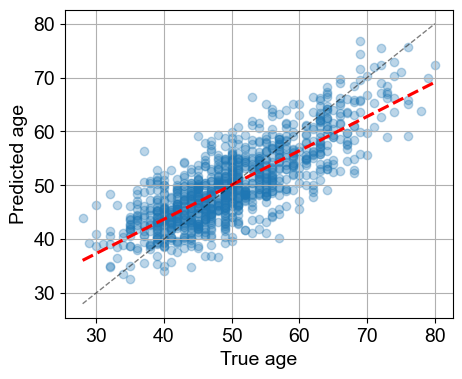

In [44]:
# Define the range of values for the age axis
l = np.arange(df["Age"].min(), df["Age"].max() + 1, 1)

# Set the figure size for the plot
plt.figure(figsize=(5, 4))

# Create a scatter plot with a regression line
sns.regplot(
    data=df, 
    x="Age", 
    y="Predicted_age", 
    scatter_kws={'alpha': 0.3},  # Set transparency for scatter points
    line_kws={'color': 'red', 'linestyle': '--'},  # Customize regression line style
    ci=None  # Remove confidence interval shading
)

# Add a diagonal line representing the identity (True = Predicted)
plt.plot(l, l, c="black", alpha=0.5, linestyle="--", linewidth=1)

# Set x and y axis labels
plt.xlabel("True age", fontsize=14)
plt.ylabel("Predicted age", fontsize=14)

# Adjust font size for both axes' ticks
plt.tick_params(axis='both', which='major', labelsize=14)

# Display gridlines
plt.grid()

# Save the figure as a PDF
plt.savefig('../figure/Figure4A.pdf', bbox_inches="tight")

## Figure4B: True Age vs Adjusted Residual Variability Scatter Plot

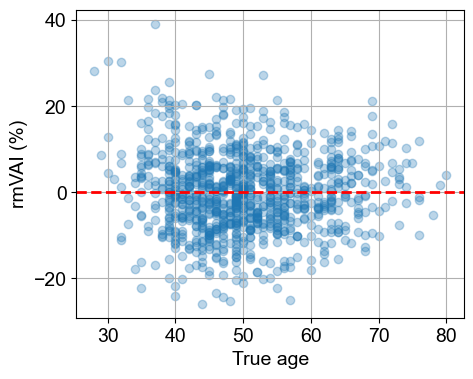

In [45]:
# Set the target column for residual variability
tgt_cols = "rmVAI (%)"

# Create the figure for plotting
fig = plt.figure(figsize=(5, 4))
# Scatter plot with transparency for data points
plt.scatter(df['Age'], df[tgt_cols], alpha=0.3)
# Add a horizontal red dashed line at y=0 for reference
plt.axhline(0, color="red", linestyle="--", linewidth=2)
# Set axis labels
plt.xlabel("True age", fontsize=14)
plt.ylabel(tgt_cols, fontsize=14)
# Enable gridlines for better readability
plt.grid()
# Adjust font size for both x and y axis ticks
plt.tick_params(axis='both', which='major', labelsize=14)

# Save the plot as a PDF with tight bounding box to avoid excess whitespace
plt.savefig('../figure/Figure4B.pdf', bbox_inches="tight")

## Figure 4C: Scatter Plot Visualization with Correlation and Regression Analysis

In [ ]:
from scipy.stats import pearsonr

# Function to plot scatter plots and calculate correlation coefficients by hue, then export to CSV
def plot_scatter_and_correlation(df,
                                 target_var="rmVAI (%)",
                                 output_folder_fig="scatter_plots",
                                 output_folder_csv="summary",
                                 xlim=None,  # Optional: x-axis limits
                                 ylim=None): # Optional: y-axis limits
    
    if target_var not in df.columns:
        print(f"'{target_var}' is not found in the DataFrame.")
        return

    # Create output directories if they do not exist
    os.makedirs(output_folder_fig, exist_ok=True)
    os.makedirs(output_folder_csv, exist_ok=True)

    # Get numerical columns
    numerical_columns = df.select_dtypes(include=["number"]).columns

    # Initialize lists to store correlation, regression, and y=0 results
    correlation_summary = []
    regression_summary = []
    y_zero_summary = []

    # Loop through numerical columns and calculate correlation and regression
    for col in numerical_columns:
        if col == target_var:
            continue

        # Drop missing values
        clean_data = df[[target_var, col]].dropna()

        try:
            # Calculate Pearson correlation
            correlation, p_value = pearsonr(clean_data[target_var], clean_data[col])
            correlation_summary.append({
                "Variable": col,
                "Correlation": correlation,
                "p-value": p_value
            })

            # Calculate regression line
            X = sm.add_constant(clean_data[col])
            model = sm.OLS(clean_data[target_var], X).fit()
            intercept, slope = model.params
            regression_summary.append({
                "Variable": col,
                "Intercept": intercept,
                "Slope": slope
            })

            # Calculate x-value at y = 0
            if slope != 0:
                x_at_y_zero = -intercept / slope
                y_zero_summary.append({
                    "Variable": col,
                    "X_at_Y_Zero": x_at_y_zero
                })
            
        except ValueError as e:
            print(f"Could not calculate correlation or regression for {col} : {e}")
            continue

        # Plot scatter plot
        plt.figure(figsize=(5, 4))
        sns.scatterplot(data=clean_data, 
                        x=col, y=target_var, alpha=0.6)
        # Set xlim and ylim if provided
        if xlim is not None:
            plt.xlim(xlim)
        if ylim is not None:
            plt.ylim(ylim)
        plt.xlabel(col, fontsize=14)
        plt.ylabel(target_var, fontsize=14)
        plt.grid()
        
        # Plot regression line
        x_range = np.linspace(clean_data[col].min(), clean_data[col].max(), 100)
        y_range = intercept + slope * x_range
        plt.plot(x_range, y_range, label=f"y={intercept:.2f}+{slope:.2f}x")        
        plt.legend()

        # Save the figure
        sanitized_col = sanitize_filename(col)
        output_path = os.path.join(output_folder_fig, f"scatter_{target_var}_vs_{sanitized_col}.pdf")
        plt.savefig(output_path, bbox_inches="tight")
        plt.close()

    # Save correlation summary to CSV
    correlation_df = pd.DataFrame(correlation_summary)
    correlation_output_path = os.path.join(output_folder_csv, "correlation_summary.csv")
    correlation_df.to_csv(correlation_output_path, index=False)

    # Save regression summary to CSV
    regression_df = pd.DataFrame(regression_summary)
    regression_output_path = os.path.join(output_folder_csv, "regression_summary.csv")
    regression_df.to_csv(regression_output_path, index=False)

    # Save y=0 summary to CSV
    y_zero_df = pd.DataFrame(y_zero_summary)
    y_zero_output_path = os.path.join(output_folder_csv, "y_zero_summary.csv")
    y_zero_df.to_csv(y_zero_output_path, index=False)

    print(f"Scatter plots saved in the '{output_folder_fig}' folder.")
    print(f"Correlation coefficients, regression summaries, and y=0 summaries saved in the '{output_folder_csv}' folder.")

In [ ]:
# Call the function with the specified parameters
plot_scatter_and_correlation(df,
                             target_var="rmVAI (%)",
                             output_folder_fig="../figure/Figure4C",
                             output_folder_csv="../processed_data/Tables_Figure4C")

## Figure 4DEF: Scatter Plots with Correlation and Regression by Hue

In [ ]:
from matplotlib.lines import Line2D

# Function to plot scatter plots with hue, calculate correlations by hue, and export results to CSV
def plot_scatter_and_correlation_hue(df, 
                                     target_var="rmVAI(%)",
                                     hue_col=None, 
                                     hue_title=None,
                                     output_folder_fig="scatter_plots", 
                                     output_folder_csv="summary", 
                                     hue_order=None):
    if target_var not in df.columns:
        print(f"'{target_var}' is not found in the DataFrame.")
        return

    if hue_col not in df.columns:
        print(f"'{hue_col}' is not found in the DataFrame.")
        return

    # Create output directories if they do not exist
    os.makedirs(output_folder_fig, exist_ok=True)
    os.makedirs(output_folder_csv, exist_ok=True)

    # Get numerical columns, excluding binary variables
    numerical_columns = df.select_dtypes(include=["number"]).columns
    numerical_columns = [col for col in numerical_columns if df[col].nunique() > 2]

    # DataFrames to store correlation coefficients, regression coefficients, and y=0 values
    correlation_summary = []
    regression_summary = []
    y_zero_summary = []

    for col in numerical_columns:
        if col == target_var:
            continue

        # Drop missing values
        clean_data = df[[target_var, col, hue_col]].dropna()

        # Get hue order
        if hue_order is None:
            hue_order = clean_data[hue_col].unique()

        # Calculate correlation for each hue group
        hue_groups = clean_data.groupby(hue_col)
        for hue_value, group in hue_groups:
            try:
                # Calculate correlation coefficient
                correlation, p_value = pearsonr(group[target_var], group[col])
                correlation_summary.append({
                    "Variable": col,
                    "Hue": hue_value,
                    "Correlation": correlation,
                    "p-value": p_value
                })

                # Calculate regression line coefficients
                X = sm.add_constant(group[col])
                model = sm.OLS(group[target_var], X).fit()
                intercept, slope = model.params
                regression_summary.append({
                    "Variable": col,
                    "Hue": hue_value,
                    "Intercept": intercept,
                    "Slope": slope
                })

                # Calculate x-value where y = 0
                if slope != 0:
                    x_at_y_zero = -intercept / slope
                    y_zero_summary.append({
                        "Variable": col,
                        "Hue": hue_value,
                        "X_at_Y_Zero": x_at_y_zero
                    })
            except ValueError as e:
                print(f"Could not calculate correlation or regression for {col} in hue {hue_value}: {e}")
                continue

        # Plotting
        # Get color mapping using seaborn default palette
        palette = sns.color_palette(n_colors=len(hue_order))
        color_map = dict(zip(hue_order, palette))

        # Initial plot setup
        fig, ax = plt.subplots(figsize=(5.5, 4.5))
        sns.scatterplot(data=clean_data, x=col, y=target_var, hue=hue_col, hue_order=hue_order, alpha=0.6, legend=False)

        # Create legend labels and handles manually
        labels = []
        handles = []
        
        # Process each group for regression lines
        for i, hue_value in enumerate(hue_order):
            try:
                group = hue_groups.get_group(hue_value)
                print(f"Processing group {hue_value} with {len(group)} data points")

                # Get the color for this hue group
                color = color_map[hue_value]
                
                # Perform regression
                X = sm.add_constant(group[col])
                model = sm.OLS(group[target_var], X).fit()
                intercept, slope = model.params
                
                # Calculate regression line coordinates
                x_range = np.linspace(group[col].min(), group[col].max(), 100)
                y_range = intercept + slope * x_range
                
                # Plot regression line
                ax.plot(x_range, y_range, color=color, linewidth=2)
                # Create legend entry
                if intercept >= 0:                
                    label = f"{hue_value}:\ny={slope:.2f}x+{intercept:.2f}"
                else:
                    label = f"{hue_value}:\ny={slope:.2f}x{intercept:.2f}"
                handle = Line2D([0], [0], color=color, marker='o', markersize=6, linestyle='-')
                
                labels.append(label)
                handles.append(handle)
                
            except Exception as e:
                print(f"Error processing group {hue_value}: {e}")
                
        # Increase font size for axis ticks
        ax.tick_params(axis='both', labelsize=16)
        plt.axhline(0, color="gray", linestyle="--", linewidth=1)
        plt.xlabel(col, fontsize=16)
        plt.ylabel(target_var, fontsize=16)
        # Display legend (with title and position)
        lg = plt.legend(handles, labels, 
                       bbox_to_anchor=(1.05, 0.5), 
                       loc='center left',
                       borderaxespad=0, 
                       fontsize=16, 
                       title=hue_title)
        
        # Set font size for legend title
        lg.get_title().set_fontsize(16)
        
        plt.grid()

        # Save the plot
        sanitized_col = sanitize_filename(col)
        output_path = os.path.join(output_folder_fig, f"scatter_{target_var}_vs_{sanitized_col}.pdf")
        plt.savefig(output_path, bbox_inches="tight")
        plt.close()

    # Save correlation summary to CSV
    correlation_df = pd.DataFrame(correlation_summary)
    correlation_output_path = os.path.join(output_folder_csv, "correlation_summary.csv")
    correlation_df.to_csv(correlation_output_path, index=False)

    # Save regression summary to CSV
    regression_df = pd.DataFrame(regression_summary)
    regression_output_path = os.path.join(output_folder_csv, "regression_summary.csv")
    regression_df.to_csv(regression_output_path, index=False)

    # Save y=0 summary to CSV
    y_zero_df = pd.DataFrame(y_zero_summary)
    y_zero_output_path = os.path.join(output_folder_csv, "y_zero_summary.csv")
    y_zero_df.to_csv(y_zero_output_path, index=False)

    print(f"Scatter plots saved in the '{output_folder_fig}' folder.")
    print(f"Correlation coefficients, regression summaries, and y=0 summaries saved in the '{output_folder_csv}' folder.")

In [ ]:
# Modify the target column for the hue to human-readable format
df["drug treatment for elevated blood pressure"] = df["drug treatment for elevated blood pressure"].map({0: "No", 1: "Yes"})
hue_order = ["No", "Yes"]
plot_scatter_and_correlation_hue(df, target_var="rmVAI (%)",
                                 hue_col='drug treatment for elevated blood pressure',
                                 hue_title="Drug treatment for\nhypertension",
                                 hue_order=hue_order,
                                 output_folder_fig="../figure/Figure4D",
                                 output_folder_csv="../processed_data/Tables_Figure4D")

In [14]:
df["drug treatment for dyslipidemia"] = df["drug treatment for dyslipidemia"].map({0: "No", 1: "Yes"})
hue_order = ["No","Yes"]
plot_scatter_and_correlation_hue(df, target_var="rmVAI (%)",
                                 hue_col='drug treatment for dyslipidemia',
                                 hue_title="Drug treatment for\ndyslipidemia",
                                 hue_order=hue_order,
                                 output_folder_fig="../figure/Figure4E",
                                 output_folder_csv="../processed_data/Tables_Figure4E")

Processing group No with 895 data points
Processing group Yes with 112 data points
Processing group No with 895 data points
Processing group Yes with 112 data points
Processing group No with 895 data points
Processing group Yes with 112 data points
Processing group No with 895 data points
Processing group Yes with 112 data points
Processing group No with 895 data points
Processing group Yes with 112 data points
Processing group No with 894 data points
Processing group Yes with 112 data points
Processing group No with 894 data points
Processing group Yes with 112 data points
Processing group No with 894 data points
Processing group Yes with 112 data points
Processing group No with 894 data points
Processing group Yes with 112 data points
Processing group No with 661 data points
Processing group Yes with 93 data points
Processing group No with 662 data points
Processing group Yes with 93 data points
Processing group No with 661 data points
Processing group Yes with 93 data points
Process

In [15]:
df["drug treatment for elevated blood glucose"] = df["drug treatment for elevated blood glucose"].map({0: "No", 1: "Yes"})
hue_order = ["No","Yes"]
plot_scatter_and_correlation_hue(df, target_var="rmVAI (%)",
                                 hue_col='drug treatment for elevated blood glucose',
                                 hue_title="Drug treatment for\ndiabetes",
                                 hue_order=hue_order,
                                 output_folder_fig="../figure/Figure4E",
                                 output_folder_csv="../processed_data/Tables_Figure4E")

Processing group No with 954 data points
Processing group Yes with 52 data points
Processing group No with 954 data points
Processing group Yes with 52 data points
Processing group No with 954 data points
Processing group Yes with 52 data points
Processing group No with 954 data points
Processing group Yes with 52 data points
Processing group No with 954 data points
Processing group Yes with 52 data points
Processing group No with 953 data points
Processing group Yes with 52 data points
Processing group No with 953 data points
Processing group Yes with 52 data points
Processing group No with 953 data points
Processing group Yes with 52 data points
Processing group No with 953 data points
Processing group Yes with 52 data points
Processing group No with 708 data points
Processing group Yes with 45 data points
Processing group No with 709 data points
Processing group Yes with 45 data points
Processing group No with 708 data points
Processing group Yes with 45 data points
Processing group

# Figure 5 and 6

### Threshold-based Categorization of 'rmVAI (%)' for Model Predictions

In [46]:
# Set the threshold for categorizing the data
th = 10
# Create a new column 'Model-predicted' and initialize with "neutral"
df["Model-predicted"] = "neutral"
# Assign "older" if 'rmVAI (%)' is greater than or equal to the threshold
df.loc[df["rmVAI (%)"] >= th, "Model-predicted"] = "older"
# Assign "younger" if 'rmVAI (%)' is less than or equal to the negative threshold
df.loc[df["rmVAI (%)"] <= -th, "Model-predicted"] = "younger"

# Define color mapping for the categories
import matplotlib.colors as mcolors
younger_hex = mcolors.to_hex(sns.color_palette("tab10")[0])  # Color for "younger"
older_hex = mcolors.to_hex(sns.color_palette("tab10")[1])  # Color for "older"

# Convert the 'Model-predicted' column to a categorical data type
df["Model-predicted"] = df["Model-predicted"].astype("category")

### Determining Metabolic Syndrome Diagnosis

In [47]:
def check_metabolic_syndrome(df):
    # Handle rows with NA values by returning False
    # Waist circumference criteria
    waist_criteria = (
        ((df['Waist circumference (cm)'].notna()) & (df['Waist circumference (cm)'] >= 85) & (df['SEX'] == 1)) | 
        ((df['Waist circumference (cm)'].notna()) & (df['Waist circumference (cm)'] >= 90) & (df['SEX'] == 0))
    )
    
    # Risk factor determination (False for NA values)
    bp_risk = (
        (df['SBP (mmHg)'].notna() & df['DBP (mmHg)'].notna()) & 
        ((df['SBP (mmHg)'] >= 130) | (df['DBP (mmHg)'] >= 85))
    )
    
    glucose_risk = (
        df['FPG (mg/dL)'].notna() & 
        (df['FPG (mg/dL)'] >= 110)
    )
    
    lipid_risk = (
        (df['TG (mg/dL)'].notna() & df['HDL (mg/dL)'].notna()) & 
        ((df['TG (mg/dL)'] >= 150) | 
         (df['HDL (mg/dL)'] <= 40))
    )
    
    # Count the number of risk factors (True=1, False=0)
    risk_count = bp_risk.astype(int) + glucose_risk.astype(int) + lipid_risk.astype(int)
    
    # Diagnosis of metabolic syndrome (meets waist criteria and has at least 2 risk factors)
    return waist_criteria & (risk_count >= 2)

In [48]:
# Apply metabolic syndrome classification to the dataframe
df["Mets"] = "Normal"
df.loc[check_metabolic_syndrome(df), "Mets"] = "Metabolic syndrome"

### BMI calculation

In [49]:
df["BMI"]=df['Weight (kg)']/(df['Height (cm)']/100)**2

### FLI calculation

In [27]:
x = np.e**(0.953*np.log(df["TG (mg/dL)"])+ \
           0.139*(df["BMI"]) +\
           0.718*np.log(df["γGTP (Unit/L)"])+ \
           0.053*df["Waist circumference (cm)"] - 15.745)

df["Fatty liver index (FLI)"] = x/(1+x)*100

## Figure 5A: Scatter Plot of True Age and Predicted rmVAI(%) with Thresholds

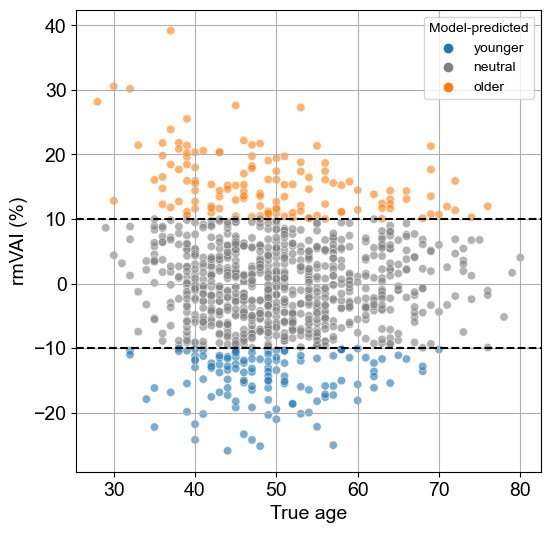

In [17]:
th = 10
tgt_cols = "rmVAI (%)"

# Create the plot
fig = plt.figure(figsize=(6, 6))

# Scatter plot
sns.scatterplot(data=df,
                x="Age",
                y=tgt_cols,
                hue="Model-predicted",
                hue_order=["younger", "neutral", "older"],  # Explicitly define the color order
                palette=[younger_hex, "gray", older_hex],
                alpha=0.6)

# Add threshold lines
plt.axhline(y=th, color="black", linestyle="--")
plt.axhline(y=-th, color="black", linestyle="--")

# Set grid and axis labels
plt.grid()
plt.xlabel("True age", fontsize=14)
plt.ylabel(tgt_cols, fontsize=14)

# Change font size of the axis ticks
plt.tick_params(axis='both', which='major', labelsize=14)

# Save the figure
plt.savefig('../figure/Figure5A.pdf', bbox_inches="tight")

## Figure 5B-F, 6A-D: Box Plot Visualization and Statistical Comparison of Numeric Variables by Class

In [50]:
from scipy.stats import mannwhitneyu

def plot_numeric_columns_box(df, class_column, output_dir_fig, output_dir_csv, order=None, font_size=14):
    # Check if the class column exists in the DataFrame
    if class_column not in df.columns:
        print(f"The specified class column '{class_column}' is not in the DataFrame.")
        return

    # Create output directories if they don't exist
    os.makedirs(output_dir_fig, exist_ok=True)
    os.makedirs(output_dir_csv, exist_ok=True)

    # Initialize a list to store statistical summaries
    stats_summary = []

    # Set the font size for the plot
    plt.rcParams.update({'font.size': font_size})

    # Loop through numerical columns in the DataFrame
    for column in df.select_dtypes(include=[np.number]).columns:
        if column == class_column:
            continue

        # Clean up the column name for use in file names
        column_filename = re.sub(r'[\\/:*?"<>|\^\$\{\}\(\) ]+', '', column)
        plt.figure(figsize=(3,4))

        # Create a box plot for the specified column and class
        sns.boxplot(x=df[class_column], y=df[column], order=order, sym="")
        
        # Overlay individual data points with a strip plot
        ax = sns.stripplot(x=df[class_column], y=df[column], jitter=0.25, size=2, alpha=0.5,
                           linewidth=0.3, order=order)

        # Adjust the line thickness
        for line in ax.lines:
            line.set_linewidth(1)

        # Add statistical annotation
        groups = df.groupby(class_column)[column]
        if all(groups.var() > 0):  # Ensure variance is positive for valid comparisons
            pairs = [(order[0], order[1])] if order and len(order) > 1 else None
            for pair in pairs:
                x1, x2 = pair
                group1 = df[df[class_column] == x1][column].dropna()
                group2 = df[df[class_column] == x2][column].dropna()
                # Perform Mann-Whitney U test for non-parametric comparison
                stat, p = mannwhitneyu(group1, group2, alternative='two-sided')
                ax.annotate(f'p={p:.3e}', xy=(0.5, 0.95), xycoords='axes fraction', ha='center', fontsize=font_size)
                # Append the results to the summary
                stats_summary.append({
                    "Variable": column,
                    "Comparison": f"{x1} vs {x2}",
                    f"Mean_{x1}": group1.mean(),
                    f"Std_{x1}": group1.std(),
                    f"n_{x1}": len(group1),
                    f"Mean_{x2}": group2.mean(),
                    f"Std_{x2}": group2.std(),
                    f"n_{x2}": len(group2),
                    "p-value": p
                })

        # Set axis labels with specified font size
        plt.xlabel(class_column, fontsize=font_size)
        plt.ylabel(column, fontsize=font_size)

        # Add margins to the x-axis
        plt.margins(x=0.25)
        # Add a margin to the y-axis and set a maximum limit
        ax.set_ylim(top=np.max([1.2 * df[column].max(), 4]))

        # Display the sample size for each class on the plot
        for i, cls in enumerate(order):
            n_count = len(df[df[class_column] == cls][column].dropna())
            ax.text(i, df[column].max(), f'n={n_count}', ha="center", va="bottom", fontsize=font_size, color="black")

        # Save the plot as a PDF
        output_path = os.path.join(output_dir_fig, f'{column_filename}_vs_{class_column}.pdf')
        plt.savefig(output_path, bbox_inches="tight")
        plt.close()

    # Convert the statistical summary to a DataFrame and save it as a CSV
    stats_df = pd.DataFrame(stats_summary)
    stats_output_path = os.path.join(output_dir_csv, "stats_summary.csv")
    stats_df.to_csv(stats_output_path, index=False)
    print(f"Statistics summary saved in {stats_output_path}")

    # Confirm that the plots have been saved
    print(f"Plots saved in {output_dir_fig}")

In [51]:
th=10
df_up = df.loc[df["rmVAI (%)"]>=th,].copy()
df_down = df.loc[df["rmVAI (%)"]<=-th,].copy()

df_up["Model-predicted"] = "older"
df_down["Model-predicted"] = "younger"
df_new = pd.concat([df_up, df_down])

plot_numeric_columns_box(df_new, class_column="Model-predicted", 
                     output_dir_fig="../figure/Figure5_6_box", 
                     output_dir_csv="../processed_data/summary_Figure5_6_box", 
                     order=["younger", "older"])

Statistics summary saved in ../processed_data/summary_Figure5_6_box/stats_summary.csv
Plots saved in ../figure/Figure5_6_box


### Figure 5G and 6EF: categorical data classification

In [52]:
from scipy.stats import chi2_contingency

def analyze_categorical_indicator(df_new, tgt_col, tgt_class, tgt_class_order, conditions, output_folder, font_size=14, legend_title=None):
    """
    Analyzes and visualizes a categorical indicator with a Chi-square test.

    Parameters:
    -----------
    df_new : DataFrame
        DataFrame containing the data for analysis.
    tgt_col : str
        The target column for the categorical variable.
    tgt_class : str
        The name of the classification column.
    tgt_class_order : list
        The order of classes for the target column.
    conditions : list of tuple
        A list of (condition function, class name) pairs for classification.
    output_folder : str
        The folder where the results will be saved.
    font_size : int, optional
        The font size for the plot (default is 14).
    legend_title : str, optional
        The title of the legend (default is the target column name).
    """
    # Remove rows with NA values in the target column
    df_new_tmp = df_new.loc[~df_new[tgt_col].isna(), :].copy()

    # Classify based on conditions
    df_new_tmp[tgt_class] = conditions[0][1]  # Default class
    for condition, class_name in conditions[1:]:
        df_new_tmp.loc[condition(df_new_tmp), tgt_class] = class_name

    # Create a contingency table
    cross_tab = pd.crosstab(df_new_tmp["Model-predicted"], df_new_tmp[tgt_class])
    order = ["younger", "older"]
    cross_tab = cross_tab.reindex(order)
    cross_tab = cross_tab.reindex(columns=tgt_class_order).fillna(0)
    cross_tab = cross_tab.loc[:, (cross_tab != 0).any(axis=0)]  # Remove columns with all zeros
    cross_tab_norm = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100  # Normalize by row

    # Perform Chi-square test
    chi2, p_value, dof, expected = chi2_contingency(cross_tab)
    print_test_results(chi2, p_value, dof, expected, cross_tab_norm)

    # Set the legend title
    title = legend_title if legend_title is not None else tgt_col

    # Plot and save the graph
    plot_and_save_graphs(cross_tab_norm, tgt_col, tgt_class, p_value, chi2, 
                         output_folder, font_size, title)


def print_test_results(chi2, p_value, dof, expected, cross_tab_norm):
    """
    Prints the results of the Chi-square test.

    Parameters:
    -----------
    chi2 : float
        The Chi-square statistic.
    p_value : float
        The p-value from the test.
    dof : int
        The degrees of freedom.
    expected : array
        The expected frequencies.
    cross_tab_norm : DataFrame
        The normalized contingency table.
    """
    print("Chi-square statistic:", chi2)
    print("p-value:", p_value)
    print("Degrees of freedom:", dof)
    print("Expected frequencies:")
    print(expected)
    print(cross_tab_norm)


def plot_and_save_graphs(cross_tab_norm, tgt_col, tgt_class, p_value, chi2, 
                        output_folder, font_size, legend_title):
    """
    Plots and saves the results of the analysis.

    Parameters:
    -----------
    cross_tab_norm : DataFrame
        The normalized contingency table.
    tgt_col : str
        The target column.
    tgt_class : str
        The target classification column.
    p_value : float
        The p-value from the Chi-square test.
    chi2 : float
        The Chi-square statistic.
    output_folder : str
        The folder where the plots will be saved.
    font_size : int
        The font size for the plots.
    legend_title : str
        The title for the legend in the plot.
    """
    # Create directories for saving the plots
    os.makedirs(os.path.join(output_folder, "ns"), exist_ok=True)
    os.makedirs(os.path.join(output_folder, "sig"), exist_ok=True)

    # Main bar plot
    fig, ax = plt.subplots(figsize=(5, 4))
    cross_tab_norm.plot(kind='bar', stacked=True, ax=ax, colormap="viridis")

    # Set plot labels and legend
    ax.set_ylabel('Percentage', fontsize=font_size)
    ax.set_xlabel("Model-predicted", fontsize=font_size)
    ax.legend(title=legend_title, bbox_to_anchor=(1.05, 1), loc='upper left',
              fontsize=font_size - 2, title_fontsize=font_size)
    ax.tick_params(axis='both', labelsize=font_size)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=0)

    # Display p-value on the plot
    p_text = f"Chi²={chi2:.1f}, p={p_value:.2e}"
    ax.text(0.5, 1.05, p_text, transform=ax.transAxes, ha="center", 
            fontsize=font_size, color="black")

    # Save the plot based on the p-value
    output_f = os.path.join(output_folder, "sig" if p_value < 0.05 else "ns")
    plt.savefig(os.path.join(output_f, f"{tgt_class}.pdf"), bbox_inches="tight")

    # Individual bar plots for each category
    colors = dict(zip(['younger', 'older'], sns.color_palette("tab10")[:2]))
    for name in cross_tab_norm.columns:
        plt.figure(figsize=(4, 3))
        cross_tab_norm[name].plot(kind="bar", edgecolor="black", fontsize=font_size, color=[colors[x] for x in cross_tab_norm.index])
        plt.ylabel(f"{name} (%)", fontsize=font_size)
        plt.xticks(rotation=0)
        plt.grid(axis="y", linestyle="--", alpha=0.7)
        plt.savefig(os.path.join(output_f, f"{tgt_class}_{name}.pdf"), bbox_inches="tight")

### Figure 5G

Chi-square statistic: 8.441473430548793
p-value: 0.003667589677118493
Degrees of freedom: 1
Expected frequencies:
[[103.98425197  20.01574803]
 [109.01574803  20.98425197]]
Mets                Normal  Metabolic syndrome
Model-predicted                               
younger          91.129032            8.870968
older            76.923077           23.076923


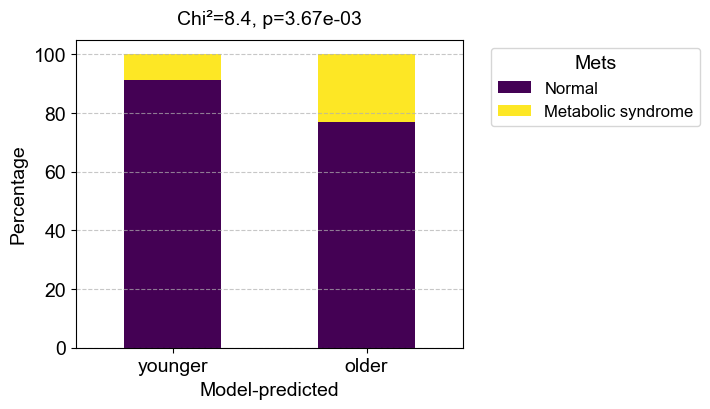

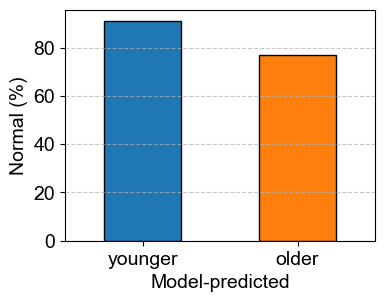

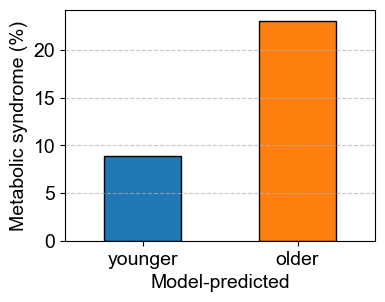

In [53]:
tgt_col = 'Waist circumference (cm)'
tgt_class = "Mets"
tgt_class_order = ['Normal', "Metabolic syndrome"]

conditions_metabolic_syndrome = [
    (lambda x: True, "Normal"),
    (check_metabolic_syndrome, "Metabolic syndrome")
]

analyze_categorical_indicator(
    df_new,
    tgt_class,
    tgt_class,
    tgt_class_order,
    conditions_metabolic_syndrome,
    "../figure/Figure5G",
    legend_title="Mets"
)

### Figure 6EF

Chi-square statistic: 9.241627092858637
p-value: 0.009844783613823769
Degrees of freedom: 2
Expected frequencies:
[[69.03557312 30.14229249 23.82213439]
 [72.96442688 31.85770751 25.17786561]]
class_FLI              Low  Intermediate status (30-60)  \
Model-predicted                                           
younger          64.227642                    23.577236   
older            48.461538                    25.384615   

class_FLI        Hepatic steatosis (>60)  
Model-predicted                           
younger                        12.195122  
older                          26.153846  


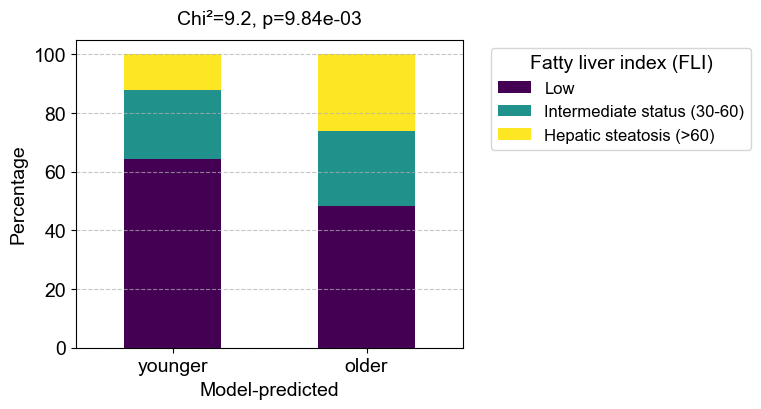

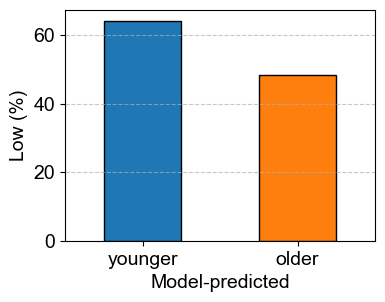

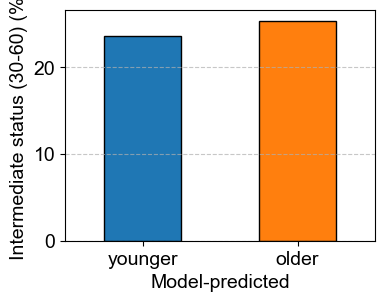

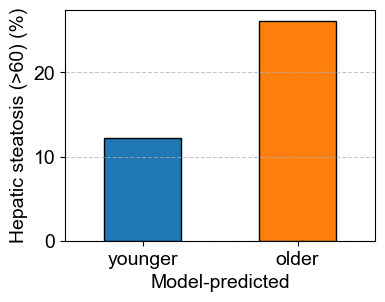

In [54]:
tgt_col = "Fatty liver index (FLI)"
tgt_class = "class_FLI"
tgt_class_order = ["Low", "Intermediate status (30-60)", "Hepatic steatosis (>60)"]

conditions_FLI = [
    (lambda x: True, "Low"),
    (lambda x: x[tgt_col]>=30, "Intermediate status (30-60)"),
    (lambda x: x[tgt_col]>60, "Hepatic steatosis (>60)")
]
analyze_categorical_indicator(
    df_new,
    tgt_col,
    tgt_class,
    tgt_class_order,
    conditions_FLI,
    "../figure/Figure6EF",
)